# 🛣️ Fase 1 — Detección de Baches con Random Forest + HOG
**Curso:** Inteligencia Artificial Aplicada | Deep Learning  
**Universidad Andina del Cusco — Escuela de Ingeniería de Sistemas**

## Pipeline de la Fase 1
```
Imagen vial completa
       ↓
Recorte de parches usando anotaciones YOLO (.txt)
       ↓
Redimensionar a 64×64 px + Escala de grises
       ↓
Extracción de características HOG → vector 1D
       ↓
Random Forest → Clasificación: ¿Bache? Sí / No
       ↓
Métricas: F1-Score, Accuracy, Matriz de Confusión
```
> **Limitación declarada:** Este modelo clasifica parches estáticos de 64×64 px.  
> No realiza detección con bounding boxes en imagen completa. Eso es objetivo de la Fase 2 (YOLO11n).

##  1. Descompresión del Dataset

In [15]:
import zipfile, os

zip_path     = "/content/archive (1).zip"   # mismo zip que Fase 2
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("✔ Dataset descomprimido correctamente")

# Verificar estructura
for root, dirs, files in os.walk("/content/dataset"):
    print(root)

✔ Dataset descomprimido correctamente
/content/dataset
/content/dataset/test
/content/dataset/test/labels
/content/dataset/test/images
/content/dataset/valid
/content/dataset/valid/labels
/content/dataset/valid/images
/content/dataset/train
/content/dataset/train/labels
/content/dataset/train/images


##  2. Conteo de imágenes por split

In [16]:
DATA_DIR = "/content/dataset"
splits   = ["train", "valid", "test"]

print("=== CONTEO DE IMÁGENES ===")
for split in splits:
    path = os.path.join(DATA_DIR, split, "images")
    if os.path.exists(path):
        print(f"  {split.capitalize():6s}: {len(os.listdir(path))} imágenes ✅")
    else:
        print(f"  {split.capitalize():6s}: carpeta no encontrada ❌")

=== CONTEO DE IMÁGENES ===
  Train : 3345 imágenes ✅
  Valid : 397 imágenes ✅
  Test  : 198 imágenes ✅


##  3. Imports

In [17]:
import os, glob, random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)

# ── Reproducibilidad ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Hiperparámetros del parche ──
PATCH_SIZE  = 64    # píxeles (ancho y alto)
N_SAMPLES   = 100   # imágenes a procesar (subset)

print("✅ Imports listos")
print(f"   Patch size : {PATCH_SIZE}×{PATCH_SIZE} px")
print(f"   Subset     : {N_SAMPLES} imágenes")
print(f"   Semilla    : {SEED}")

✅ Imports listos
   Patch size : 64×64 px
   Subset     : 100 imágenes
   Semilla    : 42


##  4. Extracción de parches positivos y negativos

- **Parche positivo:** región recortada usando la bounding box YOLO → contiene bache
- **Parche negativo:** región aleatoria de la imagen sin superposición con ninguna caja → asfalto normal

Esto transforma el problema de detección (Fase 2) en clasificación binaria (Fase 1).

In [18]:
def iou(boxA, boxB):
    """Intersection over Union entre dos cajas [x1,y1,x2,y2]."""
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return inter / float(areaA + areaB - inter + 1e-6)


def extract_patches(img_path, lbl_path, patch_size=64):
    """
    Dado un par imagen/label YOLO devuelve:
      patches_pos : lista de arrays 64×64 (bache)
      patches_neg : lista de arrays 64×64 (asfalto normal)
    """
    img = cv2.imread(img_path)
    if img is None:
        return [], []
    H, W = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ── Leer anotaciones YOLO → cajas absolutas ──
    boxes = []
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = int((cx - bw/2) * W); y1 = int((cy - bh/2) * H)
                x2 = int((cx + bw/2) * W); y2 = int((cy + bh/2) * H)
                x1, y1 = max(0,x1), max(0,y1)
                x2, y2 = min(W,x2), min(H,y2)
                if x2 > x1 and y2 > y1:
                    boxes.append([x1, y1, x2, y2])

    patches_pos, patches_neg = [], []

    # ── Parches positivos ──
    for box in boxes:
        crop = gray[box[1]:box[3], box[0]:box[2]]
        if crop.size == 0:
            continue
        patches_pos.append(cv2.resize(crop, (patch_size, patch_size)))

    # ── Parches negativos (misma cantidad, sin solapar cajas) ──
    attempts = 0
    while len(patches_neg) < len(patches_pos) and attempts < 200:
        attempts += 1
        rx = random.randint(0, max(0, W - patch_size))
        ry = random.randint(0, max(0, H - patch_size))
        rand_box = [rx, ry, rx + patch_size, ry + patch_size]
        # Verificar que no solapa con ningún bache
        if all(iou(rand_box, b) < 0.1 for b in boxes):
            crop = gray[ry:ry+patch_size, rx:rx+patch_size]
            if crop.shape == (patch_size, patch_size):
                patches_neg.append(crop)

    return patches_pos, patches_neg


print("✅ Función extract_patches definida")

✅ Función extract_patches definida


## 5. Construir dataset de parches (100 imágenes de train)

In [19]:
all_imgs = glob.glob(os.path.join(DATA_DIR, "train", "images", "*.jpg"))
selected = random.sample(all_imgs, min(N_SAMPLES, len(all_imgs)))

X_pos, X_neg = [], []

for img_path in selected:
    lbl_path = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")
    pos, neg = extract_patches(img_path, lbl_path, PATCH_SIZE)
    X_pos.extend(pos)
    X_neg.extend(neg)

print(f"Parches positivos (bache)  : {len(X_pos)}")
print(f"Parches negativos (asfalto): {len(X_neg)}")
print(f"Total de parches           : {len(X_pos) + len(X_neg)}")

Parches positivos (bache)  : 297
Parches negativos (asfalto): 297
Total de parches           : 594


##  6. Visualización de parches de muestra

/tmp/ipykernel_17435/936975789.py:16: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17435/936975789.py:16: UserWarning: Glyph 11035 (\N{BLACK LARGE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17435/936975789.py:17: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/muestras_parches.png", dpi=150)
/tmp/ipykernel_17435/936975789.py:17: UserWarning: Glyph 11035 (\N{BLACK LARGE SQUARE}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/muestras_parches.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11035 (\N{BLACK LARGE SQUARE}) missing from font(s) DejaVu S

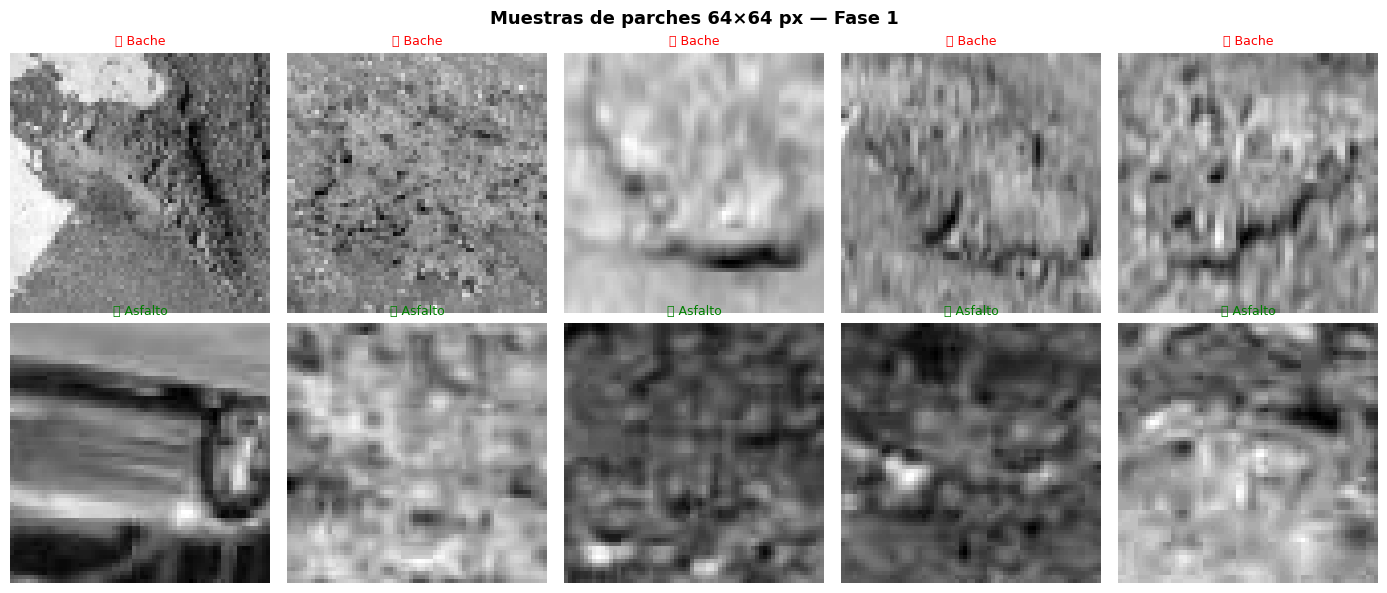

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Muestras de parches 64×64 px — Fase 1", fontsize=13, fontweight="bold")

for i, ax in enumerate(axes[0]):
    if i < len(X_pos):
        ax.imshow(X_pos[i], cmap="gray")
        ax.set_title("✅ Bache", color="red", fontsize=9)
    ax.axis("off")

for i, ax in enumerate(axes[1]):
    if i < len(X_neg):
        ax.imshow(X_neg[i], cmap="gray")
        ax.set_title("⬛ Asfalto", color="green", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("/content/muestras_parches.png", dpi=150)
plt.show()

##  7. Extracción de características HOG

HOG (Histogram of Oriented Gradients) convierte cada parche 2D en un vector 1D que captura la distribución de gradientes de intensidad — es decir, los bordes y texturas del bache — sin necesitar aprender esa representación (a diferencia de una CNN).

Shape de X       : (594, 1764)  → 594 muestras, 1764 features HOG
Distribución de y: [297 297]  (0=asfalto, 1=bache)


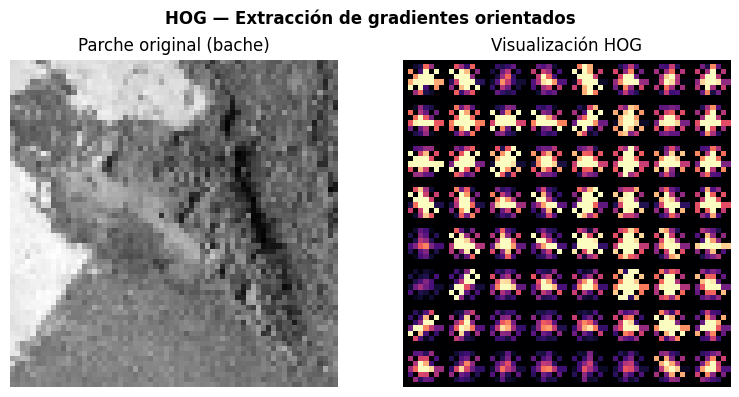

In [21]:
HOG_PARAMS = dict(
    orientations  = 9,
    pixels_per_cell = (8, 8),
    cells_per_block = (2, 2),
    block_norm    = "L2-Hys",
)

def patch_to_hog(patch):
    return hog(patch, **HOG_PARAMS)

# ── Construir X, y ──
features_pos = [patch_to_hog(p) for p in X_pos]
features_neg = [patch_to_hog(p) for p in X_neg]

X = np.array(features_pos + features_neg)
y = np.array([1]*len(features_pos) + [0]*len(features_neg))

print(f"Shape de X       : {X.shape}  → {X.shape[0]} muestras, {X.shape[1]} features HOG")
print(f"Distribución de y: {np.bincount(y)}  (0=asfalto, 1=bache)")

# Visualizar HOG de un parche
from skimage.feature import hog as skimage_hog
from skimage import exposure

if len(X_pos) > 0:
    _, hog_img = skimage_hog(X_pos[0], **HOG_PARAMS, visualize=True)
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
    ax1.imshow(X_pos[0], cmap="gray"); ax1.set_title("Parche original (bache)"); ax1.axis("off")
    ax2.imshow(hog_img_rescaled, cmap="magma"); ax2.set_title("Visualización HOG"); ax2.axis("off")
    plt.suptitle("HOG — Extracción de gradientes orientados", fontweight="bold")
    plt.tight_layout()
    plt.savefig("/content/hog_visualizacion.png", dpi=150)
    plt.show()

##  8. División Train / Test

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.25,
    random_state = SEED,
    stratify     = y
)

print(f"Train : {X_train.shape[0]} muestras")
print(f"Test  : {X_test.shape[0]}  muestras")
print(f"Clases en train: {np.bincount(y_train)}")
print(f"Clases en test : {np.bincount(y_test)}")

Train : 445 muestras
Test  : 149  muestras
Clases en train: [222 223]
Clases en test : [75 74]


## 🌲 9. Entrenamiento del Random Forest

**Justificación de hiperparámetros:**
- `n_estimators=100` → 100 árboles para estabilidad del ensemble (bagging)
- `max_depth=None` → permite que cada árbol crezca hasta separar todas las clases
- `class_weight='balanced'` → compensa si hay desbalance entre parches positivos y negativos

In [23]:
import time

rf = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = None,
    class_weight = "balanced",
    random_state = SEED,
    n_jobs       = -1
)

t0 = time.time()
rf.fit(X_train, y_train)
t1 = time.time()

print(f"✅ Modelo entrenado en {t1-t0:.2f} segundos")
print(f"   Árboles       : {rf.n_estimators}")
print(f"   Features usadas: {rf.n_features_in_}")

✅ Modelo entrenado en 0.72 segundos
   Árboles       : 100
   Features usadas: 1764


##  10. Evaluación — Métricas y Matriz de Confusión

In [24]:
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average="binary")
f1w = f1_score(y_test, y_pred, average="weighted")

print("\n" + "="*45)
print("      MÉTRICAS FINALES — Random Forest")
print("="*45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  F1 Binary : {f1:.4f}  ({f1*100:.1f}%)")
print(f"  F1 Weighted: {f1w:.4f} ({f1w*100:.1f}%)")
print("="*45)
print()
print(classification_report(y_test, y_pred, target_names=["Asfalto", "Bache"]))


      MÉTRICAS FINALES — Random Forest
  Accuracy  : 0.8255  (82.6%)
  F1 Binary : 0.8243  (82.4%)
  F1 Weighted: 0.8255 (82.6%)

              precision    recall  f1-score   support

     Asfalto       0.83      0.83      0.83        75
       Bache       0.82      0.82      0.82        74

    accuracy                           0.83       149
   macro avg       0.83      0.83      0.83       149
weighted avg       0.83      0.83      0.83       149



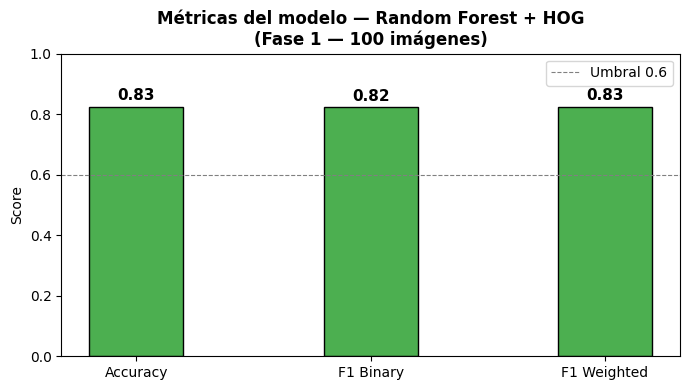

In [25]:
# ── Gráfico de barras ──
labels  = ["Accuracy", "F1 Binary", "F1 Weighted"]
values  = [acc, f1, f1w]
colors  = ["#4CAF50" if v >= 0.6 else "#FF9800" if v >= 0.4 else "#F44336" for v in values]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values, color=colors, edgecolor="black", width=0.4)
plt.ylim(0, 1.0)
plt.title("Métricas del modelo — Random Forest + HOG\n(Fase 1 — 100 imágenes)",
          fontsize=12, fontweight="bold")
plt.ylabel("Score")
plt.axhline(0.6, color="gray", linestyle="--", linewidth=0.8, label="Umbral 0.6")
plt.legend()
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/metricas_rf.png", dpi=150)
plt.show()

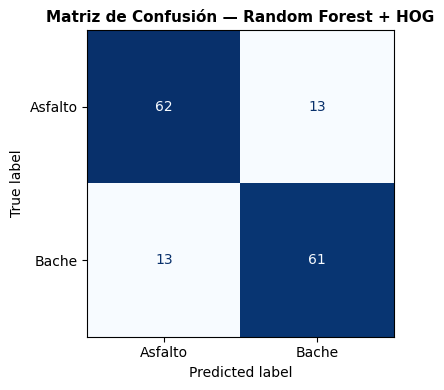

In [26]:
# ── Matriz de confusión ──
cm  = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Asfalto", "Bache"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de Confusión — Random Forest + HOG",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/confusion_matrix_rf.png", dpi=150)
plt.show()

## 11. Importancia de características HOG

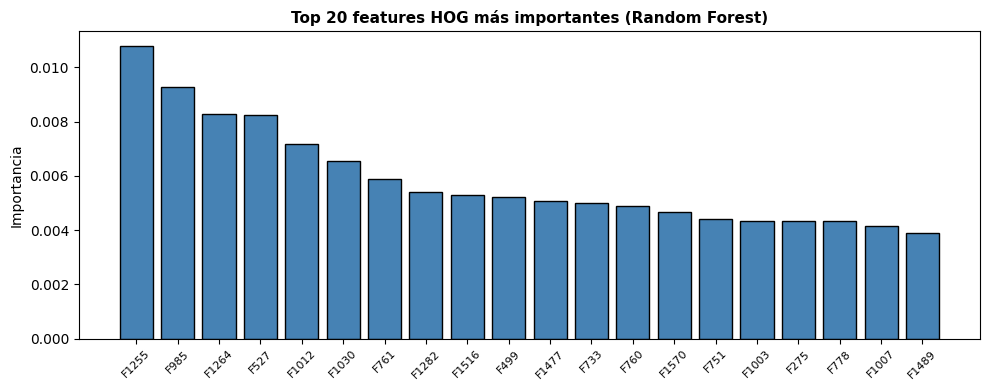

In [27]:
importances = rf.feature_importances_
top_k = 20
top_idx = np.argsort(importances)[::-1][:top_k]

plt.figure(figsize=(10, 4))
plt.bar(range(top_k), importances[top_idx], color="steelblue", edgecolor="black")
plt.xticks(range(top_k), [f"F{i}" for i in top_idx], rotation=45, fontsize=8)
plt.title(f"Top {top_k} features HOG más importantes (Random Forest)",
          fontsize=11, fontweight="bold")
plt.ylabel("Importancia")
plt.tight_layout()
plt.savefig("/content/feature_importance_rf.png", dpi=150)
plt.show()